# Identification

<a target="_blank" href="https://colab.research.google.com/github/glaucogoncalves/nio/blob/main/assignments/ilp-exec-3.ipynb"> <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jussiléa Gurjão de Figueiredo - Isolada05

# Attention, please!

Solve the problems below. Show the problem model and the solution using ```pyomo``` and the GLPK or COIN-OR solvers.

To see how to write optimization models in colab, look for examples in the Integer Linear Programming class colab.

Please send your Colab file (.ipynb) in SIGAA.

# Problem 1

Considering graph of routers of the RNP's network, which is [presented here](https://redeipe.rnp.br/panorama). From this picture code a solution that find the shortest path between routers **PE** and **GO**. You should model the graph in the colab using the library networkx (see the colab on ILP for an example of usage). You must solve the problem in two ways: by solver and using Djikstra's Algorithm (networkx implements that). Compare the solutions found and the time to obtain each one. Please set the weights as $w_{ij} = \frac{1}{\text{link capacity}}$. The link capacity can be obtained if you hover the mouse pointer over a link in the site.

In [1]:
!pip install -q pyomo
!apt install coinor-cbc

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  coinor-libcbc3 coinor-libcgl1 coinor-libclp1 coinor-libcoinutils3v5
  coinor-libosi1v5
The following NEW packages will be installed:
  coinor-cbc coinor-libcbc3 coinor-libcgl1 coinor-libclp1
  coinor-libcoinutils3v5 coinor-libosi1v5
0 upgraded, 6 newly installed, 0 to remove and 2 not upgraded.
Need to get 2,908 kB of archives.
After this operation, 8,310 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 coinor-libcoinutils3v5 amd64 2.11.4+repack1-2 [465 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 coinor-libosi1v5 amd64 0.108.6+repack1-2 [275 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 coinor-libclp1 amd64 1.17.5+repack1-1 [937 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 coinor-libcgl1 amd64 0.60.3+repack1-3 [420 kB]
Get:5 htt

In [2]:
import time
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pyomo.environ import *

In [9]:
# Dados do problema

nodes = ['AC','AL','AM','AP','BA','CE','DF','ES','GO','MA','MG','MS',
'MT','PA','PB_CGE','PB_JPA','PE','PI','PR','RJ','RN','RO','RR','RS','SC',
'SE','SP','TO']

edges = [('AC','RO',0.01),('RO','MT',0.01),('MT','DF',0.01),('MT','GO',0.1),('MT','MS',0.01),('MS','GO',0.01),('MS','PR',0.1),('GO','DF',0.005),('DF','AM',0.111),('DF','MA',0.01),('DF','TO',0.005),
         ('DF','BA',0.01),('DF','MG',0.01),('DF','SP',0.005),('AM','RR',0.01),('AM','AP',0.005),('RO','AM',0.0111),('DF','CE',0.1),('RR','CE',1),('CE','RN',0.01),('CE','PI',0.01),('CE','BA',0.01),
         ('CE','SP',0.003),('RN','PB_CGE',0.01),('AP','PA',0.01),('MT','MS',0.01),('PI','MA',0.01),('PI','BA',0.01),('SC','PR',0.005),('SC','SP',0.01),('SC','RS',0.01),('PR','SP',0.003),('PR','RS',0.005),
         ('TO','PA',0.01),('PA','MA',0.1),('PB_CGE','PE',0.01),('PB_CGE','PB_JPA',0.005),('PB_CGE','BA',0.025),('MG','SP',0.01),('MG','RJ',0.005),('MG','ES',0.1),('MG','BA',0.01),('PB_JPA','PE',0.1),
         ('RS','SP',0.01),('SP','RJ',0.005),('RJ','ES',0.01),('ES','PA',0.0033),('BA','SE',0.01),('SE','AL',0.01),('AL','PE',0.01)]


In [10]:
arcs = []

for i,j,w in edges:
    arcs.append((i,j,w))
    arcs.append((j,i,w))

model = ConcreteModel()

model.N = Set(initialize=nodes)
model.A = Set(initialize=[(i,j) for (i,j,w) in arcs])

weights = {(i,j):w for (i,j,w) in arcs}

model.w = Param(model.A, initialize=weights)

model.x = Var(model.A, domain=Binary)

def obj_rule(model):
    return sum(model.w[i,j]*model.x[i,j] for (i,j) in model.A)

model.obj = Objective(rule=obj_rule, sense=minimize)

source = 'PE'
target = 'GO'

def flow_rule(model,n):

    inflow = sum(model.x[i,j] for (i,j) in model.A if j==n)
    outflow = sum(model.x[i,j] for (i,j) in model.A if i==n)

    if n == source:
        return outflow - inflow == 1

    elif n == target:
        return inflow - outflow == 1

    else:
        return inflow - outflow == 0

model.flow = Constraint(model.N, rule=flow_rule)



In [20]:
solver_edges = []

# medir somente o tempo de resolução do solver
start_solver = time.time()
results = solver.solve(model)
end_solver = time.time()

time_solver = end_solver - start_solver

# extrair arestas selecionadas pelo solver
for (i,j) in model.A:
    if model.x[i,j].value > 0.5:
        solver_edges.append((i,j))

# reconstruir caminho ordenado
path = ['PE']
current = 'PE'

while current != 'GO':
    for (i,j) in solver_edges:
        if i == current:
            path.append(j)
            current = j
            break

print("Caminho solver:", path)
print("Tempo solver:", time_solver)

Caminho solver: ['PE', 'PB_CGE', 'RN', 'CE', 'SP', 'DF', 'GO']
Tempo solver: 0.08729696273803711


In [12]:
G = nx.Graph()

for i,j,w in edges:
    G.add_edge(i,j,weight=w)

In [13]:
start_dijkstra = time.time()

path = nx.dijkstra_path(G,'PE','GO',weight='weight')
dist = nx.dijkstra_path_length(G,'PE','GO',weight='weight')

end_dijkstra = time.time()

time_dijkstra = end_dijkstra - start_dijkstra

print("Caminho Dijkstra:", path)
print("Distância:", dist)
print("Tempo Dijkstra:", time_dijkstra)

Caminho Dijkstra: ['PE', 'PB_CGE', 'RN', 'CE', 'SP', 'DF', 'GO']
Distância: 0.043
Tempo Dijkstra: 0.0012919902801513672


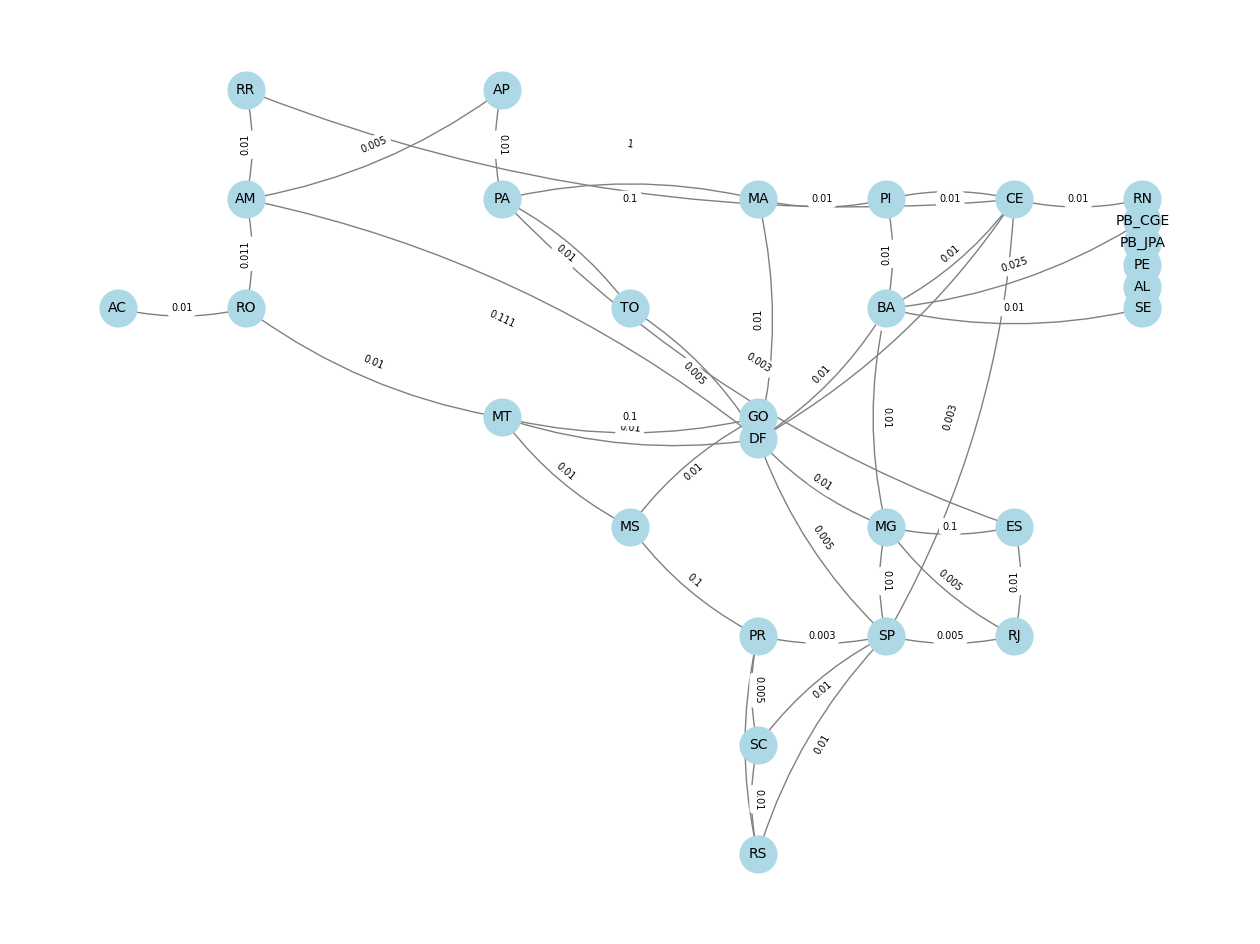

In [26]:
plt.figure(figsize=(16,12))

nx.draw_networkx_nodes(G,pos,node_color='lightblue',node_size=700)
nx.draw_networkx_labels(G,pos,font_size=10)

nx.draw_networkx_edges(
    G,pos,
    edge_color='gray',
    arrows=True,
    connectionstyle='arc3,rad=0.12'
)

labels = {e: round(w,3) for e,w in nx.get_edge_attributes(G,'weight').items()}

nx.draw_networkx_edge_labels(
    G,pos,
    edge_labels=labels,
    font_size=7
)

plt.axis('off')
plt.show()

In [21]:
print("------ COMPARAÇÃO ------")

print("Tempo solver CBC:", time_solver)
print("Tempo Dijkstra:", time_dijkstra)

------ COMPARAÇÃO ------
Tempo solver CBC: 0.08729696273803711
Tempo Dijkstra: 0.0012919902801513672


# Problem 2

A large supermarket chain in the UK needs to build warehouses for a set of supermarkets it is opening in Northern England. The locations of the supermarkets have been identified, but the locations of the warehouses have yet to be determined.

Several good candidate locations for the warehouses have been identified, but decisions must be made regarding how many warehouses to open and at which candidate locations to build them. Moreover, each supermarket has an specific demand that must be met by the warehouses. If one warehouse is not sufficient to meet the demand, other warehouses can chosen to supply the supermarket.

Opening many warehouses would be advantageous as this would reduce the average distance a truck has to drive from the warehouse to the supermarket, and hence reduce the delivery cost. However, opening a warehouse has a fixed cost associated with it.

Our goal is **to find the optimal tradeoff between delivery costs and the costs of building new facilities**.

Below is the set of supermarkets. The coordinates and demand of each supermarket are provided in the following table.

| <i></i> | Coordinates | Demand |
| --- | --- | --- |
| Supermarket 1 | (0,1.5) | 16,000 |
| Supermarket 2 | (2.5,1.2) | 18,000 |
| Supermarket 3 | (4,4) | 12,000 |
| Supermarket 3 | (1.0,1.3) | 17,000 |
| Supermarket 3 | (1.5,2.2) | 20,000 |

The following table shows the coordinates of the candidate warehouse sites, the fixed cost of building the warehouse in millions dollar, and its respective capacity.

| <i></i> | coordinates | fixed cost | Capacity |
| --- | --- |  --- | --- |
| Warehouse 1 | (0,0) | 3 | 30,000 |
| Warehouse 2 | (0,1) | 2 | 10,000 |
| Warehouse 3 | (0,2) | 3 | 12,000 |
| Warehouse 4 | (1,0) | 1 | 8,000 |
| Warehouse 5 | (1,1) | 3 | 15,000 |
| Warehouse 6 | (1,2) | 3 | 22,000 |
| Warehouse 7 | (2,0) | 4 | 10,000 |
| Warehouse 8 | (2,1) | 3 | 30,000 |
| Warehouse 9 | (2,2) | 2 | 20,000 |

The transport cost is one million dollar per kilometer.

Formulate an ILP model and solve it.